In [1]:
import matplotlib.pyplot as plt
import math
import numpy as np
import time

import jax
import jax.numpy as jnp
import optax

from jax import random

In [2]:
activation_function = jax.nn.tanh # defines tanh as activation function

def u(x):
  """Exact solution of the PDE"""
  return x * jnp.exp(-x**2)

def rhs(x):
  """Defines the right hand side of the equation"""
  return (4*x**3 - 6*x) * jnp.exp(-x**2)

In [3]:
# Domain of x
x_lower = 0
x_upper = 1

n  = 256
key_x = jax.random.PRNGKey(136)
key_y = jax.random.PRNGKey(871)

X = jax.random.uniform(
    key=key_x, shape=(n, 1),
    minval=x_lower, maxval=x_upper
)
X_test = jnp.linspace(x_lower, x_upper, 1000).reshape((1000, 1))
Y_test = X_test * jnp.exp(-X_test**2)


In [144]:
# hyperparameters
width = [1] + 3*[5] + [1]
learning_rate = 1e-4
b1 = 0.9
b2 = 0.999
eps = 1e-08
eps_root = 0.0

In [145]:
initializer = jax.nn.initializers.glorot_normal() # Glorot initialization
key    = jax.random.split(jax.random.PRNGKey(136), len(width) - 1)
params = list()

for key, lin, lout in zip(key, width[:-1], width[1:]):
  W = initializer(key, (lin, lout), jnp.float32)
  B = initializer(key, (1, lout)  , jnp.float32)
  params.append({'W': W, 'B': B})

In [146]:
#Initilize optimizer
optimizer = optax.adam(learning_rate, b1, b2, eps, eps_root)
opt_state = optimizer.init(params)

In [147]:
# Define function for forward pass
@jax.jit #Just in time compilation
def forward(x, params):
  *hidden, output = params
  for layer in hidden:
    x = activation_function(x @ layer['W'] + layer['B'])

  return x @ output['W'] + output['B']

In [148]:
def laplacian(f, argnum=0):
  """Defines laplacian using `jax.grad`"""
  return jax.grad(jax.grad(f, argnums=argnum), argnums=argnum)

def pde(u):
  """Defines the PDE"""
  uxx = lambda x: laplacian(f=lambda x: jnp.sum(u(x)), argnum=0)(x)
  return uxx

def MSE(pred, true):
  """Mean squared error"""
  return jnp.mean((pred - true) ** 2)

def loss_interior(x, params):
  """Find the loss in the domain of the function"""

  def u_net(x_val):
    """Calcula u(x) da rede neural"""
    x = x_val.reshape(1, 1)
    return forward(x, params)[0, 0]

  # Vetorizamos a operação
  laplacian_u = jax.vmap(pde(u_net))(x.flatten())

  # Voltamos o resultado para o formato original (N, 1) para calcular o erro
  u_xx = laplacian_u.reshape(-1, 1)
  return MSE(u_xx, rhs(x))

@jax.jit
def loss_function(params, x):
  pde_loss = loss_interior(x, params)

  bc_0 = MSE(forward(jnp.array([[0.0]]), params), 0.0)
  bc_1 = MSE(forward(jnp.array([[1.0]]), params), jnp.exp(-1.0))

  boundary_loss = bc_0 + bc_1

  return pde_loss + boundary_loss

In [149]:
#Define the gradient function
grad_loss = jax.jit(jax.grad(loss_function, 0))

#Define update function
@jax.jit
def update(opt_state, params, x):
    #Compute gradient
    grads = grad_loss(params, x)
    #Calculate parameters updates
    updates, opt_state = optimizer.update(grads, opt_state)
    #Update parameters
    params = optax.apply_updates(params, updates)
    #Return state of optmizer and updated parameters
    return opt_state, params

In [150]:
epochs = 15000
t_start_train = time.time()
for e in range(epochs):
  #Update optimizer state and parameters
  opt_state, params = update(opt_state, params, X)

  if e % 1000 == 0:
    elapsed = time.time() - t_start_train
    print(f"{elapsed:.2f}s | Epoch {e:<6}: empirical loss {loss_function(params, X):.12f}")

loss_final = loss_function(params, X).block_until_ready()
train_time = time.time() - t_start_train

print(f"Treinamento concluído em {train_time:.2f}s")

t_start_eval = time.time()
Y_nn = forward(X_test.reshape((1000, 1)), params).reshape(X_test.shape)
Y_nn.block_until_ready()
eval_time = time.time() - t_start_eval

print(f"Avaliação concluída em {eval_time:.4f}s")

norma_erro = jnp.linalg.norm(Y_nn - Y_test)
norma_exata = jnp.linalg.norm(Y_test)
rel_l2_error = norma_erro / norma_exata

print(f"Erro L2 Relativo: {rel_l2_error:.8e}")

1.42s | Epoch 0     : empirical loss 0.847995460033
2.28s | Epoch 1000  : empirical loss 0.339251518250
2.81s | Epoch 2000  : empirical loss 0.223939985037
3.35s | Epoch 3000  : empirical loss 0.110364362597
3.88s | Epoch 4000  : empirical loss 0.004703207873
4.41s | Epoch 5000  : empirical loss 0.000188207894
4.94s | Epoch 6000  : empirical loss 0.000057359859
5.54s | Epoch 7000  : empirical loss 0.000029601764
6.14s | Epoch 8000  : empirical loss 0.000017879524
6.72s | Epoch 9000  : empirical loss 0.000014056428
7.36s | Epoch 10000 : empirical loss 0.000011349846
7.98s | Epoch 11000 : empirical loss 0.000008526469
8.63s | Epoch 12000 : empirical loss 0.000006008229
9.23s | Epoch 13000 : empirical loss 0.000004239875
9.78s | Epoch 14000 : empirical loss 0.000003319504
Treinamento concluído em 10.31s
Avaliação concluída em 0.1061s
Erro L2 Relativo: 3.41906270e-05


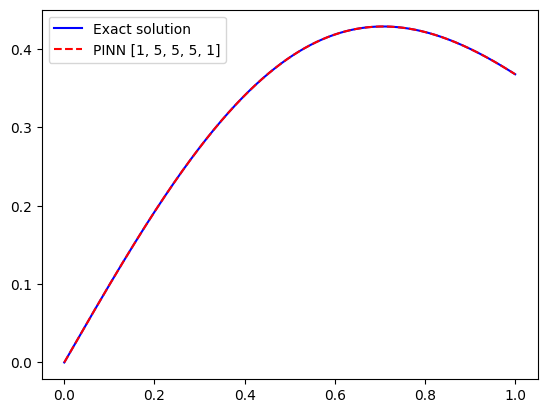

Train loss 2.899604851336335e-06
Test loss 3.0961598440626403e-06


In [151]:
plt.plot(X_test, Y_test, '-', color='blue', markersize=0.5, label='Exact solution')
plt.plot(X_test, Y_nn, '--', color='red', markersize=0.5, label=f'PINN {width}')

plt.legend(loc='best')
plt.show()

print(f"Train loss {loss_function(params, X)}")
print(f"Test loss {loss_function(params, X_test)}")

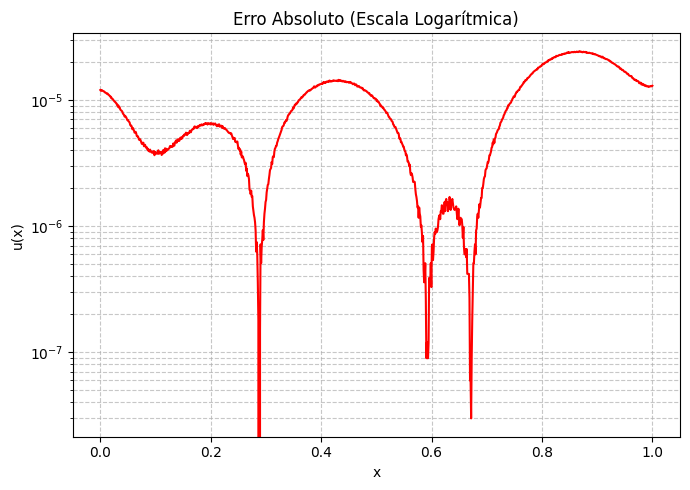

In [152]:
# Cálculo do erro absoluto de forma vetorizada (mais rápido que o loop for)
errors = jnp.abs(Y_test - Y_nn)

# Cria uma figura com 1 linha e 2 colunas para os gráficos
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

# Gráfico 2: Escala Logarítmica
ax.plot(X_test, errors, '-', color='red')
ax.set_title('Erro Absoluto (Escala Logarítmica)')
ax.set_xlabel('x')
ax.set_ylabel('u(x)')
ax.set_yscale('log') # Transforma o eixo Y em escala logarítmica
ax.grid(True, which="both", linestyle='--', alpha=0.7)

# Ajusta o layout para evitar sobreposição e plota
plt.tight_layout()
plt.show()

In [153]:
num_hidden_layers = len(width) - 2

results = {
    'architecture': width,
    'num_hidden_layers': int(num_hidden_layers),
    'epochs': epochs,
    'error_relativo': float(rel_l2_error),
    'time_training': float(train_time),
    'time_evaluation': float(eval_time),
    'y_nn': np.asarray(Y_nn)
}

# Salvando com um nome que identifique a rede
nome_arquivo = f'dados_pinn_1d_{width}.npz'
np.savez_compressed(nome_arquivo, **results)

print(f"Dados salvos com sucesso no arquivo '{nome_arquivo}'!")

Dados salvos com sucesso no arquivo 'dados_pinn_1d_[1, 5, 5, 5, 1].npz'!
